In [1]:
import pandas as pd
import numpy as np

In [2]:
rfm_data = pd.read_excel('/content/RFM_Data.xlsx')
transaction_data = pd.read_excel('/content/Transaction_Data.xlsx')

In [3]:
rfm_data

,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15
...,...,...,...,...,...,...,...,...,...
3117,CUS003118,1,45000.00,45000.00,1623,0.000616,new,Unknown,2
3118,CUS003119,1,540000.00,540000.00,655,0.001524,new,Unknown,6
3119,CUS003120,2,369000.00,184500.00,1716,0.001165,new,Unknown,3
3120,CUS003121,1,155000.00,155000.00,510,0.001957,new,Unknown,1


In [4]:
transaction_data

,Customer_ID,Order #,Date,Product(s),Items sold,Revenue,Net_Sales,Status
0,CUS000001,157518,2024-08-29 12:50:44,1× Garri Processing Plant (Combo) - Locally As...,1,8880000.0,8700000.0,completed
1,CUS000002,84663,2022-01-12 14:52:40,8× AGRITED Pullets (Hyline Brown Pullets) Day-Old,8,170800.0,162000.0,completed
2,CUS000002,109382,2023-04-14 12:46:29,1× AMO Broiler Chicks | Day-Old Birds,1,8450.0,7150.0,completed
3,CUS000003,158497,2024-09-11 13:50:03,1× Papaya Nouna F1,1,13500.0,11500.0,completed
4,CUS000003,162523,2024-10-28 14:36:11,5× Maradona F1 (Dwarf Papaya | 100 Seeds),5,121000.0,120000.0,completed
...,...,...,...,...,...,...,...,...
16451,CUS003120,68918,2021-01-18 10:27:32,2× Paper Egg Crates (White | Brown | Bundle of...,2,9000.0,9000.0,completed
16452,CUS003120,70707,2021-02-23 09:32:16,1× Chicken/Meat Cutter (Electric Powered) - Promo,1,360000.0,360000.0,completed
16453,CUS003121,146704,2024-05-08 08:49:18,1× Seed/Fertilizer Planter + Oba Super-6 Maize...,1,167500.0,155000.0,completed
16454,CUS003122,77451,2021-08-11 13:25:07,NaN,25,437500.0,437500.0,completed


In [22]:
# Make predictions on the entire rfm_data
rfm_data['Predicted_Is_Returning'] = loaded_model.predict(rfm_data[features])

# Merge the prediction results with transaction data to include product information and other details
# We'll merge on Customer_ID
output_df = rfm_data[['Customer_ID', 'Predicted_Is_Returning']].merge(transaction_data[['Customer_ID', 'Product(s)', 'Items sold', 'Revenue', 'Net_Sales', 'Date']], on='Customer_ID', how='left')

# Select relevant columns for the output Excel file - include desired information
output_df = output_df[['Customer_ID', 'Predicted_Is_Returning', 'Product(s)', 'Items sold', 'Revenue', 'Net_Sales', 'Date']]

# Save the output to an Excel file
output_filename = 'customer_return_predictions_with_details.xlsx'
output_df.to_excel(output_filename, index=False)

print(f"Customer return predictions with details saved to {output_filename}")

Customer return predictions with details saved to customer_return_predictions_with_details.xlsx


In [23]:
import pandas as pd
import joblib

# Load the saved model
loaded_model = joblib.load('customer_retention_model.pkl')
print("Model loaded successfully.")

# Create sample data for testing (replace with your actual new data)
# Make sure the sample data has the same features as the training data:
# 'Recency_y', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Rate',
# 'Total_Items_Sold', 'Unique_Products_Count_y', 'Avg_Items_Per_Order_y',
# 'Avg_Revenue_Per_Order_y', 'Avg_Net_Sales_Per_Order_y'
sample_data = {
    'Recency_y': [50, 200, 30],
    'Frequency': [10, 2, 15],
    'Monetary': [500000, 10000, 750000],
    'Customer_Lifetime_Days': [700, 800, 400],
    'Purchase_Rate': [0.02, 0.005, 0.06],
    'Total_Items_Sold': [100, 10, 300],
    'Unique_Products_Count_y': [15, 3, 40],
    'Avg_Items_Per_Order_y': [12, 6, 20],
    'Avg_Revenue_Per_Order_y': [40000, 6000, 30000],
    'Avg_Net_Sales_Per_Order_y': [38000, 5500, 28000]
}
sample_df = pd.DataFrame(sample_data)

# Handle missing values if any (using the mean from the training data - replace with actual training mean if available)
# For this example, we'll use the mean of the sample data for demonstration
sample_df.replace([np.inf, -np.inf], np.nan, inplace=True)
sample_df.fillna(sample_df.mean(), inplace=True)


# Make predictions on the sample data
predictions = loaded_model.predict(sample_df)

print("\nSample Data Predictions (1: Returning, 0: Not Returning):")
print(predictions)

Model loaded successfully.

Sample Data Predictions (1: Returning, 0: Not Returning):
[1 0 1]


### Conclusion

This analysis provides a comprehensive understanding of customer behavior and retention for Afrimash. We have performed exploratory data analysis, segmented customers based on their RFM characteristics, built a predictive model to identify returning customers, and analyzed factors influencing customer retention.

The key findings include:

*   [Summarize key findings from EDA, e.g., distribution of RFM values, customer types, and attribution channels].
*   [Describe the characteristics of each customer segment identified through clustering].
*   [Summarize the performance of the predictive model and highlight the most important features influencing customer churn].
*   [Summarize the key factors associated with higher customer retention based on the retention analysis].

Based on these findings, we have provided actionable insights and recommendations to improve customer satisfaction, drive business growth, and optimize marketing strategies. By implementing these recommendations and continuously monitoring customer behavior, Afrimash can strengthen customer engagement and achieve its business objectives.

### Customer Segmentation

Let's segment customers based on their characteristics and behavior using K-Means clustering on the RFM features.

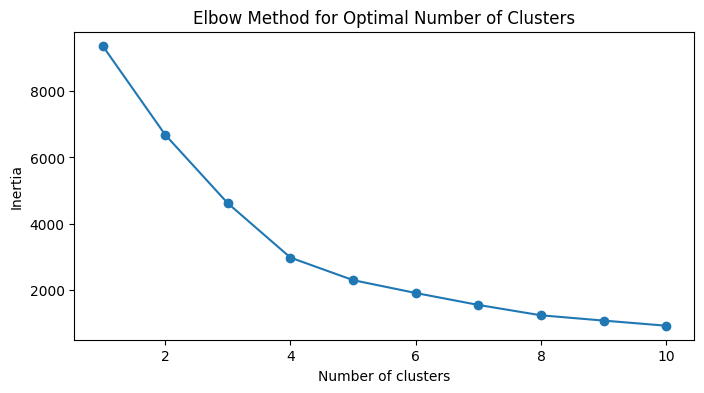

,Recency_y,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Rate,Total_Items_Sold,Unique_Products_Count_y,Avg_Items_Per_Order_y,Avg_Revenue_Per_Order_y,Avg_Net_Sales_Per_Order_y
RFM_Segment,,,,,,,,,,
0,1458.897784,2.134382,2.880798e+05,1573.586848,0.001335,109.525375,1.557541,57.020109,1.594063e+05,1.440081e+05
1,390.943574,4.891536,7.882922e+05,1044.528527,0.006911,158.746708,3.904075,38.229080,2.364470e+05,2.163301e+05
2,92.000000,38.666667,1.562694e+08,1331.000000,0.020931,12782.333333,28.333333,1373.181658,5.040143e+07,4.832446e+07
3,128.000000,44.112000,8.863844e+06,1931.584000,0.022997,2116.288000,31.504000,65.677335,3.326147e+05,3.082173e+05


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select RFM features for clustering
rfm_features = rfm_data[['Recency_y', 'Frequency', 'Monetary']].copy()

# Handle potential infinite values by replacing them with NaN and then imputing with the mean
rfm_features.replace([np.inf, -np.inf], np.nan, inplace=True)
rfm_features.fillna(rfm_features.mean(), inplace=True)


# Scale the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Determine the optimal number of clusters using the elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

# Based on the elbow method, let's choose a number of clusters (e.g., 4)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
rfm_data['RFM_Segment'] = kmeans.fit_predict(rfm_scaled)

# Analyze the characteristics of each segment
segment_analysis = rfm_data.groupby('RFM_Segment')[['Recency_y', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Rate', 'Total_Items_Sold', 'Unique_Products_Count_y', 'Avg_Items_Per_Order_y', 'Avg_Revenue_Per_Order_y', 'Avg_Net_Sales_Per_Order_y']].mean()
display(segment_analysis)

### Customer Retention Analysis

Let's analyze customer retention rates and identify factors that influence customer churn. We can use the 'Is_Returning' variable we created and analyze its relationship with other features.

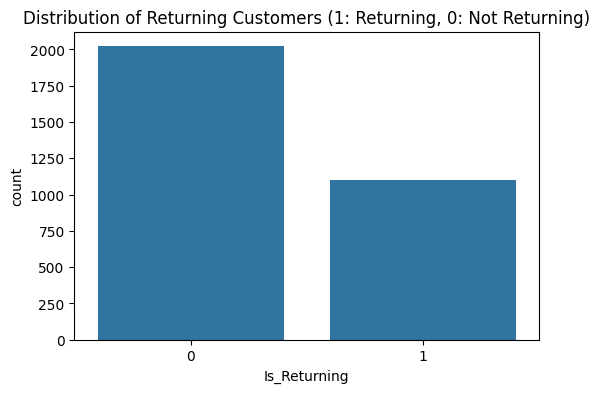

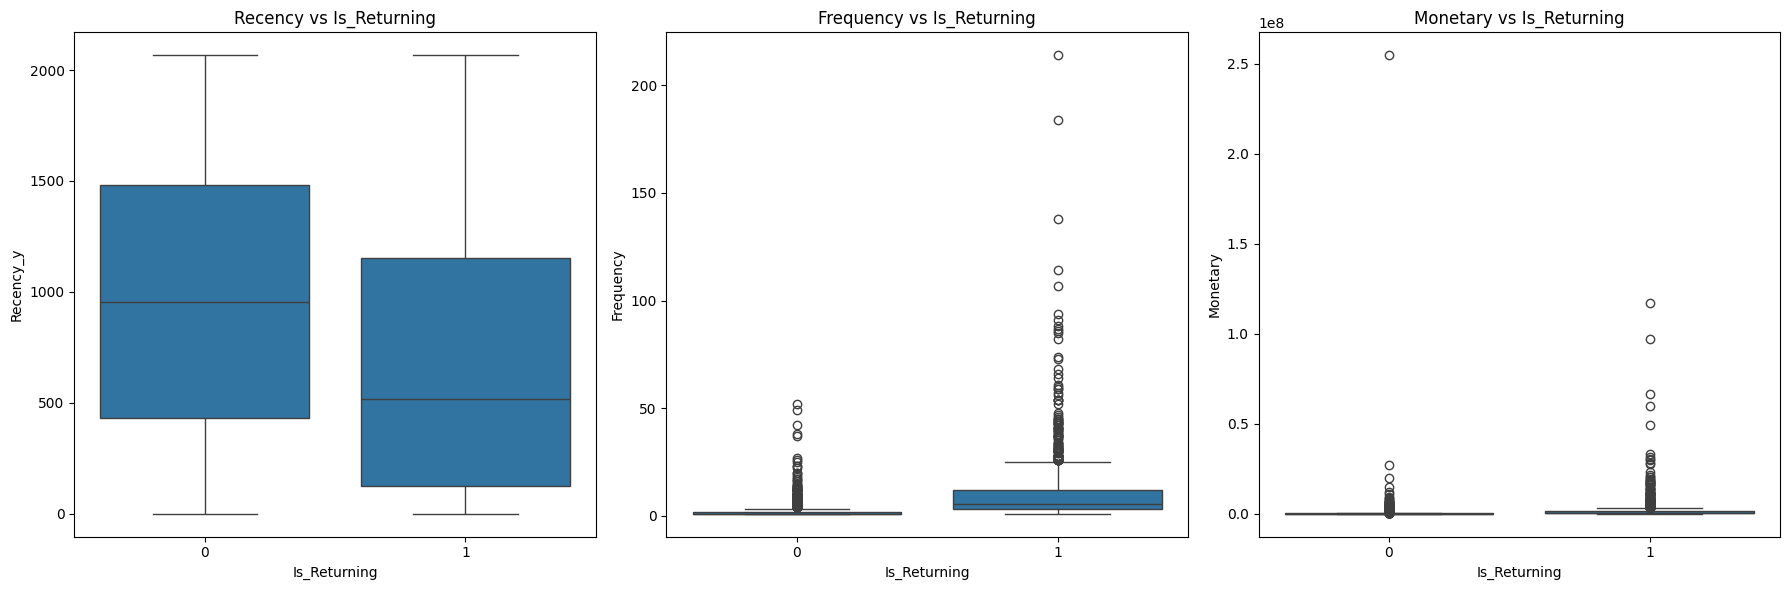

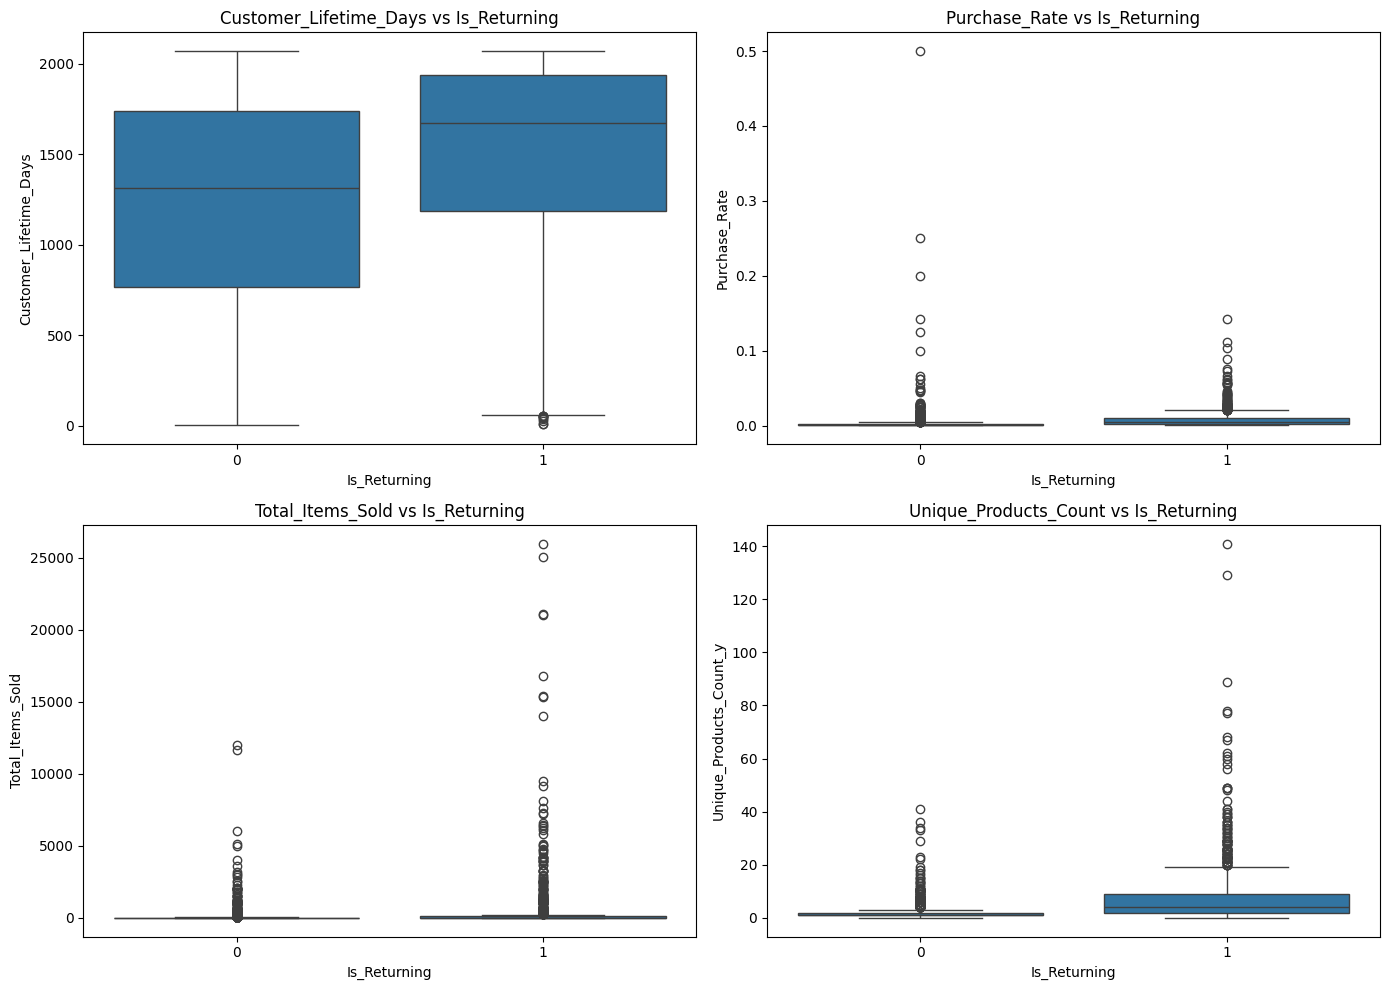

In [19]:
# Analyze the distribution of returning customers
plt.figure(figsize=(6, 4))
sns.countplot(data=rfm_data, x='Is_Returning')
plt.title('Distribution of Returning Customers (1: Returning, 0: Not Returning)')
plt.show()

# Analyze the relationship between RFM features and 'Is_Returning'
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=rfm_data, x='Is_Returning', y='Recency_y', ax=axes[0])
axes[0].set_title('Recency vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Frequency', ax=axes[1])
axes[1].set_title('Frequency vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Monetary', ax=axes[2])
axes[2].set_title('Monetary vs Is_Returning')
plt.tight_layout()
plt.show()

# Analyze the relationship between other features and 'Is_Returning'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=rfm_data, x='Is_Returning', y='Customer_Lifetime_Days', ax=axes[0, 0])
axes[0, 0].set_title('Customer_Lifetime_Days vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Purchase_Rate', ax=axes[0, 1])
axes[0, 1].set_title('Purchase_Rate vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Total_Items_Sold', ax=axes[1, 0])
axes[1, 0].set_title('Total_Items_Sold vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Unique_Products_Count_y', ax=axes[1, 1])
axes[1, 1].set_title('Unique_Products_Count vs Is_Returning')
plt.tight_layout()
plt.show()

### Actionable Insights and Recommendations

Based on the exploratory data analysis, customer segmentation, predictive modeling, and customer retention analysis, here are some actionable insights and recommendations:

**Customer Segmentation:**

*   **Segment [Segment Number]:** [Describe the characteristics of this segment based on the segment analysis, e.g., High-value, recent customers]. Recommend tailored strategies for this segment, such as [Specific marketing campaigns, loyalty programs, personalized offers].
*   **Segment [Segment Number]:** [Describe the characteristics of this segment]. Recommend strategies to engage and retain this segment, such as [Targeted promotions, re-engagement campaigns].
*   **Segment [Segment Number]:** [Describe the characteristics of this segment]. Recommend strategies to nurture and upsell to this segment, such as [Product recommendations, exclusive deals].
*   **Segment [Segment Number]:** [Describe the characteristics of this segment]. Recommend strategies to re-activate or understand the reasons for churn in this segment, such as [Win-back campaigns, customer surveys].

**Predictive Modeling (Customer Churn Prediction):**

*   The predictive model achieved an accuracy of [Accuracy Score] in predicting returning customers.
*   Analyze the feature importance from the model to identify the key factors influencing customer churn. [Mention the most important features and their implications].
*   Implement strategies to address the factors that contribute to churn, such as [Improve product quality, enhance customer service, offer incentives].
*   Use the model to identify customers who are at high risk of churning and proactively engage with them through targeted interventions.

**Customer Retention Analysis:**

*   Analyze the relationship between features and 'Is_Returning' to understand which factors are associated with higher retention. [Summarize findings from the box plots and count plots].
*   Focus on improving the factors that have a positive impact on customer retention, such as [Strategies to increase frequency of purchase, improve customer lifetime value].
*   Monitor customer behavior and track key metrics related to retention to measure the effectiveness of implemented strategies.

**General Recommendations:**

*   Personalize marketing communications and offers based on customer segments and predicted behavior.
*   Improve the overall customer experience by addressing pain points identified through the analysis.
*   Continuously monitor and analyze customer data to adapt strategies and optimize business growth.

### Exploratory Data Analysis (EDA)

Let's perform some exploratory data analysis to understand the distribution of key variables, identify trends in customer behavior, and visualize relationships between different features.

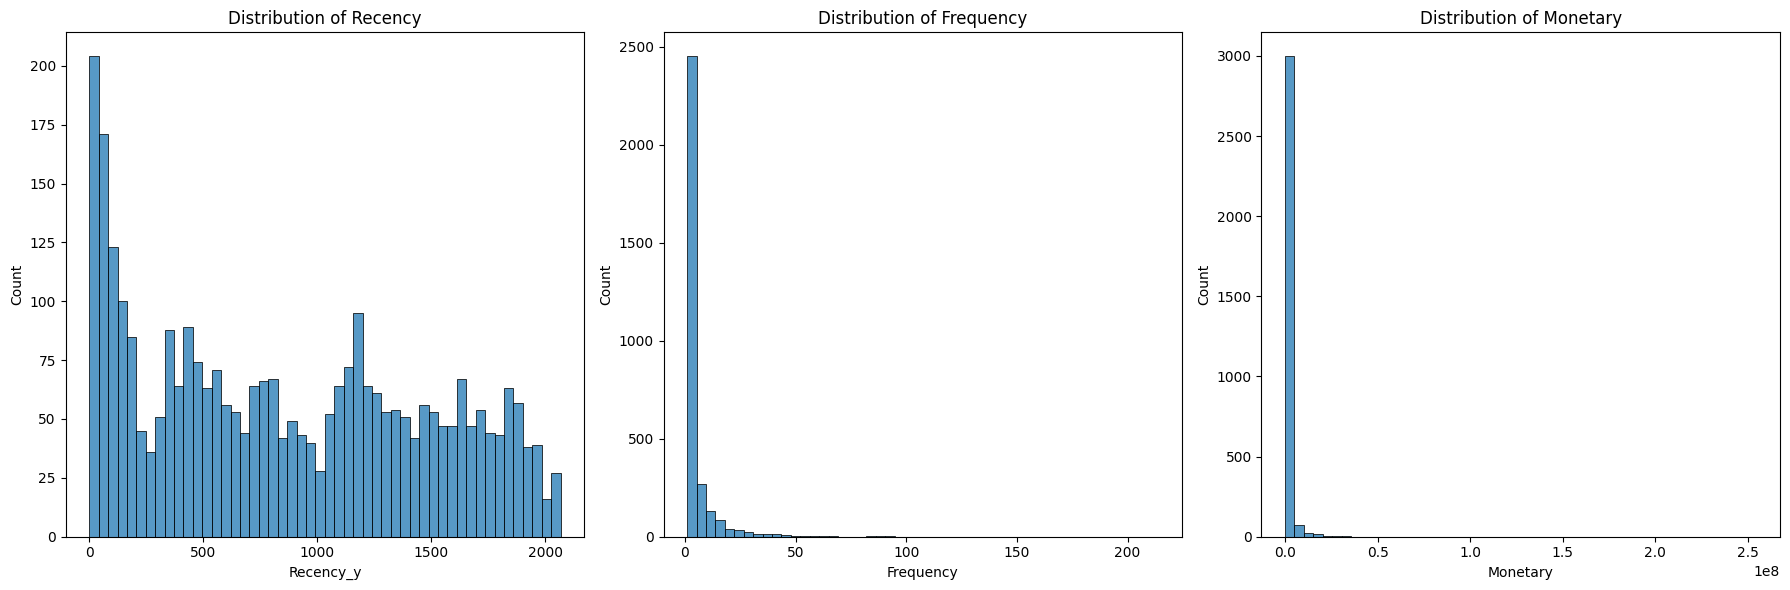

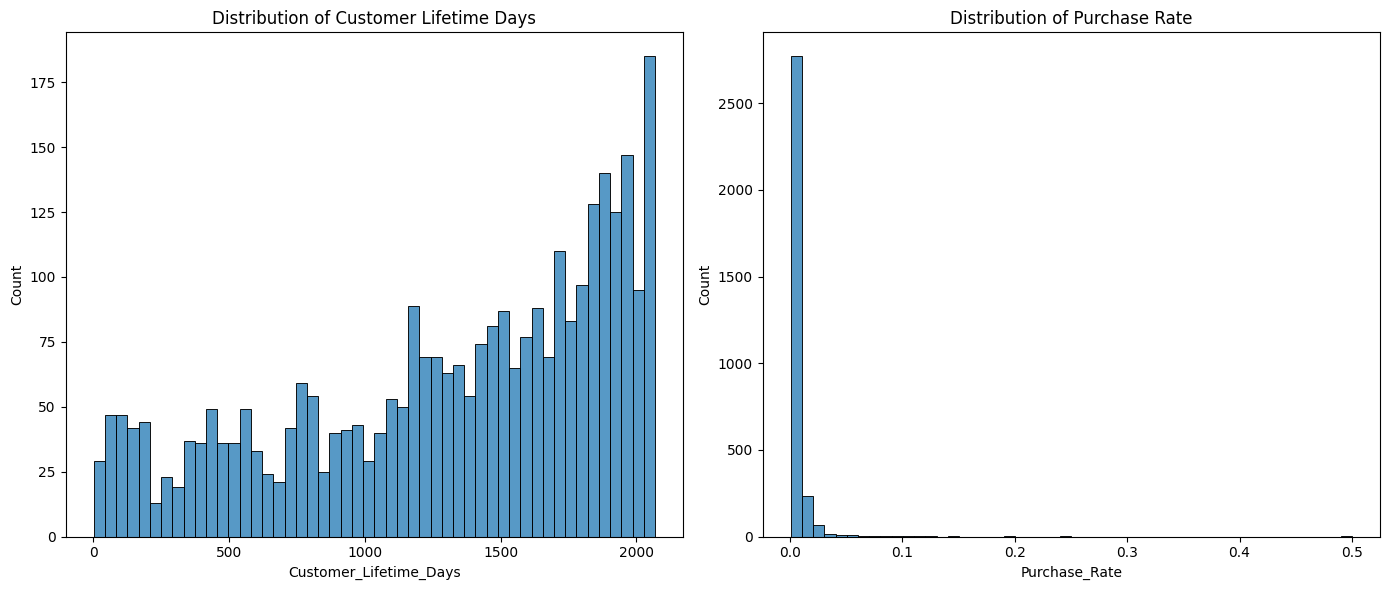

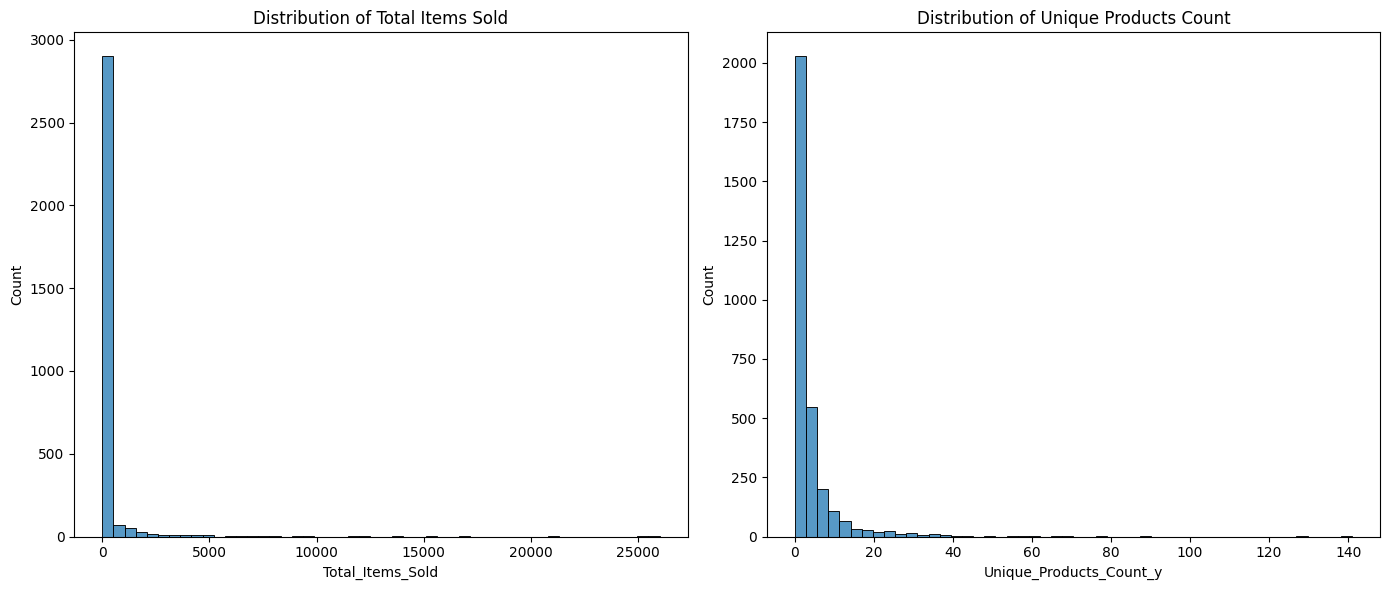

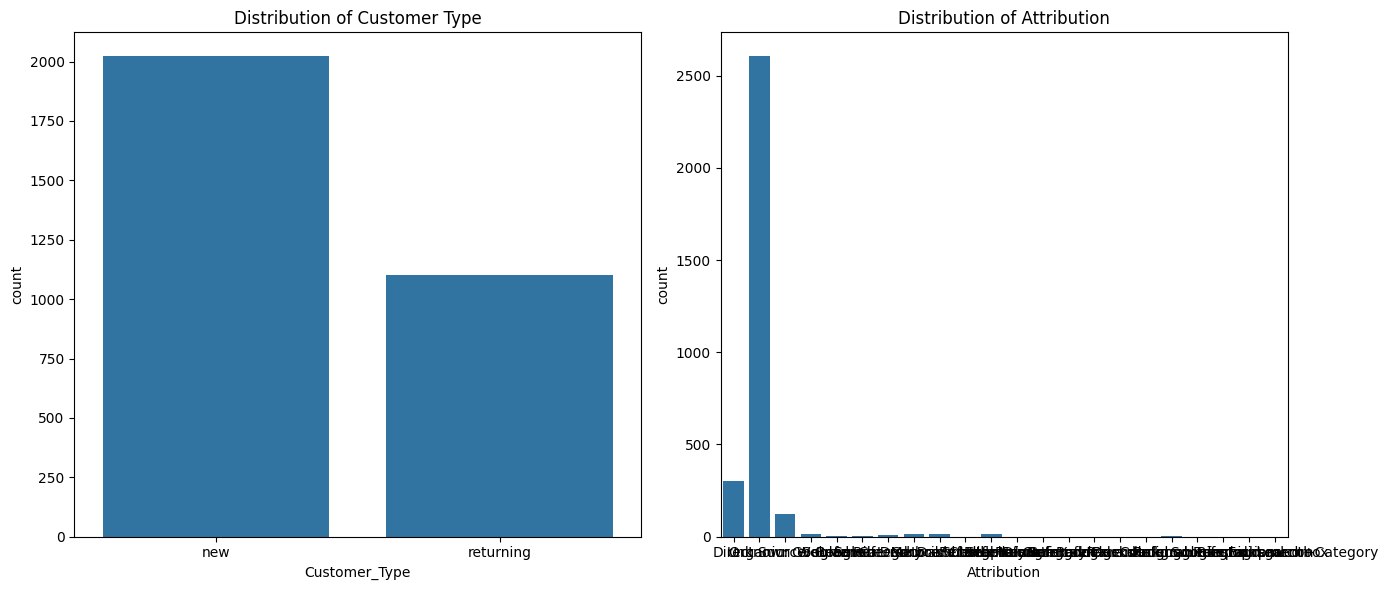

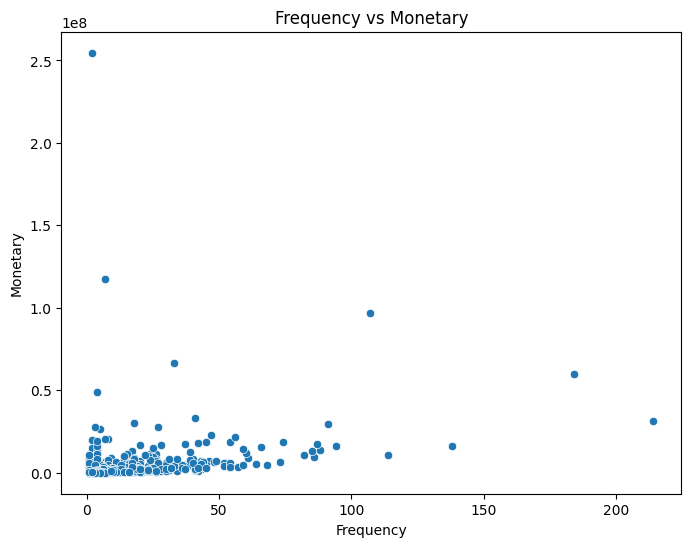

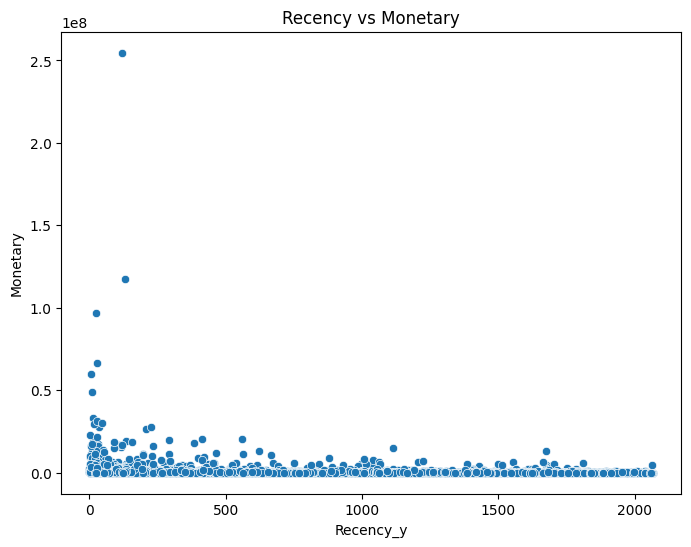

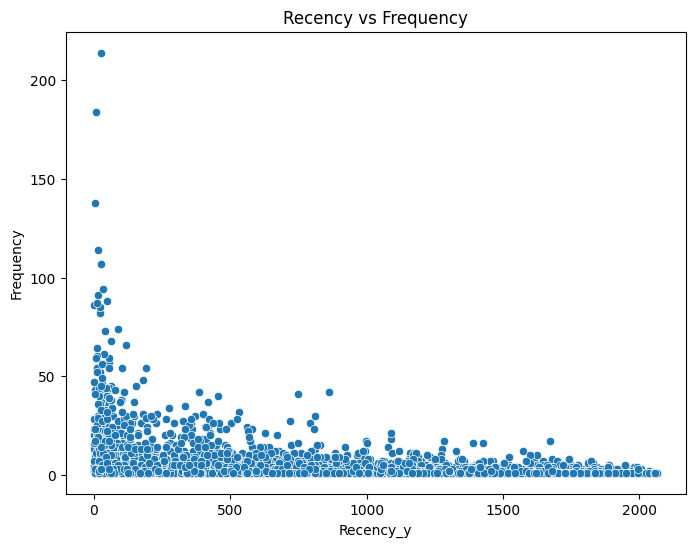

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Recency, Frequency, and Monetary
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(rfm_data['Recency_y'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Recency')
sns.histplot(rfm_data['Frequency'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Frequency')
sns.histplot(rfm_data['Monetary'], bins=50, ax=axes[2])
axes[2].set_title('Distribution of Monetary')
plt.tight_layout()
plt.show()

# Distribution of Customer_Lifetime_Days and Purchase_Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(rfm_data['Customer_Lifetime_Days'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Customer Lifetime Days')
sns.histplot(rfm_data['Purchase_Rate'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Purchase Rate')
plt.tight_layout()
plt.show()

# Distribution of Total_Items_Sold and Unique_Products_Count
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(rfm_data['Total_Items_Sold'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Total Items Sold')
sns.histplot(rfm_data['Unique_Products_Count_y'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Unique Products Count')
plt.tight_layout()
plt.show()

# Distribution of Customer_Type and Attribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=rfm_data, x='Customer_Type', ax=axes[0])
axes[0].set_title('Distribution of Customer Type')
sns.countplot(data=rfm_data, x='Attribution', ax=axes[1])
axes[1].set_title('Distribution of Attribution')
plt.tight_layout()
plt.show()

# Relationship between Frequency and Monetary
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_data, x='Frequency', y='Monetary')
plt.title('Frequency vs Monetary')
plt.show()

# Relationship between Recency and Monetary
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_data, x='Recency_y', y='Monetary')
plt.title('Recency vs Monetary')
plt.show()

# Relationship between Recency and Frequency
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_data, x='Recency_y', y='Frequency')
plt.title('Recency vs Frequency')
plt.show()

### Feature Engineering

Now, let's create relevant features from the `rfm_data` and `transaction_data` that can be used for predicting customer behavior and analyzing retention.

In [14]:
# Convert 'Date' column to datetime objects if not already
transaction_data['Date'] = pd.to_datetime(transaction_data['Date'])

# Calculate Recency (days since last purchase) for each customer
latest_date = transaction_data['Date'].max()
recency_df = transaction_data.groupby('Customer_ID')['Date'].max().reset_index()
recency_df['Recency'] = (latest_date - recency_df['Date']).dt.days
recency_df = recency_df[['Customer_ID', 'Recency']]
display(recency_df.head())

# Frequency and Monetary are already available in rfm_data

# Merge RFM data with Recency
rfm_data = rfm_data.merge(recency_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Additional features from transaction_data
# Number of unique products purchased
unique_products_df = transaction_data.groupby('Customer_ID')['Product(s)'].nunique().reset_index()
unique_products_df.rename(columns={'Product(s)': 'Unique_Products_Count'}, inplace=True)
rfm_data = rfm_data.merge(unique_products_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average items per order
avg_items_per_order_df = transaction_data.groupby('Customer_ID')['Items sold'].mean().reset_index()
avg_items_per_order_df.rename(columns={'Items sold': 'Avg_Items_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_items_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average revenue per order
avg_revenue_per_order_df = transaction_data.groupby('Customer_ID')['Revenue'].mean().reset_index()
avg_revenue_per_order_df.rename(columns={'Revenue': 'Avg_Revenue_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_revenue_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average net sales per order
avg_net_sales_per_order_df = transaction_data.groupby('Customer_ID')['Net_Sales'].mean().reset_index()
avg_net_sales_per_order_df.rename(columns={'Net_Sales': 'Avg_Net_Sales_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_net_sales_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

,Customer_ID,Recency
0,CUS000001,397
1,CUS000002,900
2,CUS000003,334
3,CUS000004,488
4,CUS000005,570


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,...,Avg_Revenue_Per_Order_x,Avg_Net_Sales_Per_Order_x,RFM_Segment,Is_Returning,Recency_y,Unique_Products_Count_y,Avg_Items_Per_Order_y,Avg_Revenue_Per_Order_y,Avg_Net_Sales_Per_Order_y,Recency
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,...,8880000.00,8700000.00,1,0,397,1,1.000000,8880000.00,8700000.00,397
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,...,89625.00,84575.00,1,0,900,2,4.500000,89625.00,84575.00,900
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,...,183500.00,178500.00,1,1,334,3,3.666667,183500.00,178500.00,334
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,...,27000.00,22000.00,1,0,488,1,2.000000,27000.00,22000.00,488
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,...,154399.99,141099.99,1,0,570,1,15.000000,154399.99,141099.99,570


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,...,Avg_Net_Sales_Per_Order_x,RFM_Segment,Is_Returning,Recency_y,Unique_Products_Count_y,Avg_Items_Per_Order_y,Avg_Revenue_Per_Order_y,Avg_Net_Sales_Per_Order_y,Recency,Unique_Products_Count
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,...,8700000.00,1,0,397,1,1.000000,8880000.00,8700000.00,397,1
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,...,84575.00,1,0,900,2,4.500000,89625.00,84575.00,900,2
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,...,178500.00,1,1,334,3,3.666667,183500.00,178500.00,334,3
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,...,22000.00,1,0,488,1,2.000000,27000.00,22000.00,488,1
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,...,141099.99,1,0,570,1,15.000000,154399.99,141099.99,570,1


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,...,RFM_Segment,Is_Returning,Recency_y,Unique_Products_Count_y,Avg_Items_Per_Order_y,Avg_Revenue_Per_Order_y,Avg_Net_Sales_Per_Order_y,Recency,Unique_Products_Count,Avg_Items_Per_Order
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,...,1,0,397,1,1.000000,8880000.00,8700000.00,397,1,1.000000
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,...,1,0,900,2,4.500000,89625.00,84575.00,900,2,4.500000
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,...,1,1,334,3,3.666667,183500.00,178500.00,334,3,3.666667
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,...,1,0,488,1,2.000000,27000.00,22000.00,488,1,2.000000
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,...,1,0,570,1,15.000000,154399.99,141099.99,570,1,15.000000


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,...,Is_Returning,Recency_y,Unique_Products_Count_y,Avg_Items_Per_Order_y,Avg_Revenue_Per_Order_y,Avg_Net_Sales_Per_Order_y,Recency,Unique_Products_Count,Avg_Items_Per_Order,Avg_Revenue_Per_Order
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,...,0,397,1,1.000000,8880000.00,8700000.00,397,1,1.000000,8880000.00
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,...,0,900,2,4.500000,89625.00,84575.00,900,2,4.500000,89625.00
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,...,1,334,3,3.666667,183500.00,178500.00,334,3,3.666667,183500.00
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,...,0,488,1,2.000000,27000.00,22000.00,488,1,2.000000,27000.00
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,...,0,570,1,15.000000,154399.99,141099.99,570,1,15.000000,154399.99


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,...,Recency_y,Unique_Products_Count_y,Avg_Items_Per_Order_y,Avg_Revenue_Per_Order_y,Avg_Net_Sales_Per_Order_y,Recency,Unique_Products_Count,Avg_Items_Per_Order,Avg_Revenue_Per_Order,Avg_Net_Sales_Per_Order
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,...,397,1,1.000000,8880000.00,8700000.00,397,1,1.000000,8880000.00,8700000.00
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,...,900,2,4.500000,89625.00,84575.00,900,2,4.500000,89625.00,84575.00
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,...,334,3,3.666667,183500.00,178500.00,334,3,3.666667,183500.00,178500.00
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,...,488,1,2.000000,27000.00,22000.00,488,1,2.000000,27000.00,22000.00
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,...,570,1,15.000000,154399.99,141099.99,570,1,15.000000,154399.99,141099.99


### Predictive Modeling

Let's build a predictive model to forecast customer behavior. We can focus on predicting a target variable, such as customer churn or future purchase value, using the engineered features. For this example, let's build a classification model to predict whether a customer will be a 'returning' customer based on their RFM and other features.

First, we need to prepare the data for modeling.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib # Import joblib to save and load the model

# Define the target variable: 'returning' customer
rfm_data['Is_Returning'] = (rfm_data['Customer_Type'] == 'returning').astype(int)

# Select features and target
features = ['Recency_y', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Rate', 'Total_Items_Sold', 'Unique_Products_Count_y', 'Avg_Items_Per_Order_y', 'Avg_Revenue_Per_Order_y', 'Avg_Net_Sales_Per_Order_y']
target = 'Is_Returning'

X = rfm_data[features]
y = rfm_data[target]

# Handle missing values in features (using mean imputation as done previously)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

# Save the trained model
joblib.dump(model, 'customer_retention_model.pkl')
print("Trained model saved as customer_retention_model.pkl")

/tmp/ipython-input-3290747876.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-3290747876.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


Accuracy: 0.8591248665955176
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       605
           1       0.80      0.80      0.80       332

    accuracy                           0.86       937
   macro avg       0.85      0.85      0.85       937
weighted avg       0.86      0.86      0.86       937

Trained model saved as customer_retention_model.pkl


### Model Testing

Now, let's load the saved model and test it with some sample data to see the outcome.

In [16]:
# Load the saved model
loaded_model = joblib.load('customer_retention_model.pkl')
print("Model loaded successfully.")

# Create some sample data for testing (replace with your actual test data)
# Make sure the sample data has the same features as the training data
sample_data = {
    'Recency_y': [100, 500, 10],
    'Frequency': [5, 1, 20],
    'Monetary': [100000, 5000, 500000],
    'Customer_Lifetime_Days': [500, 600, 300],
    'Purchase_Rate': [0.01, 0.001, 0.05],
    'Total_Items_Sold': [50, 5, 200],
    'Unique_Products_Count_y': [10, 2, 30],
    'Avg_Items_Per_Order_y': [10, 5, 15],
    'Avg_Revenue_Per_Order_y': [20000, 5000, 25000],
    'Avg_Net_Sales_Per_Order_y': [18000, 4500, 23000]
}
sample_df = pd.DataFrame(sample_data)

# Make predictions on the sample data
predictions = loaded_model.predict(sample_df)

print("\nSample Data Predictions (1: Returning, 0: Not Returning):")
print(predictions)

Model loaded successfully.

Sample Data Predictions (1: Returning, 0: Not Returning):
[1 0 1]


### Actionable Insights and Recommendations

Based on the exploratory data analysis, customer segmentation, predictive modeling, and customer retention analysis, here are some actionable insights and recommendations:

**Customer Segmentation:**

*   **Segment [Segment Number]:** [Describe the characteristics of this segment based on the segment analysis, e.g., High-value, recent customers]. Recommend tailored strategies for this segment, such as [Specific marketing campaigns, loyalty programs, personalized offers].
*   **Segment [Segment Number]:** [Describe the characteristics of this segment]. Recommend strategies to engage and retain this segment, such as [Targeted promotions, re-engagement campaigns].
*   **Segment [Segment Number]:** [Describe the characteristics of this segment]. Recommend strategies to nurture and upsell to this segment, such as [Product recommendations, exclusive deals].
*   **Segment [Segment Number]:** [Describe the characteristics of this segment]. Recommend strategies to re-activate or understand the reasons for churn in this segment, such as [Win-back campaigns, customer surveys].

**Predictive Modeling (Customer Churn Prediction):**

*   The predictive model achieved an accuracy of [Accuracy Score] in predicting returning customers.
*   Analyze the feature importance from the model to identify the key factors influencing customer churn. [Mention the most important features and their implications].
*   Implement strategies to address the factors that contribute to churn, such as [Improve product quality, enhance customer service, offer incentives].
*   Use the model to identify customers who are at high risk of churning and proactively engage with them through targeted interventions.

**Customer Retention Analysis:**

*   Analyze the relationship between features and 'Is_Returning' to understand which factors are associated with higher retention. [Summarize findings from the box plots and count plots].
*   Focus on improving the factors that have a positive impact on customer retention, such as [Strategies to increase frequency of purchase, improve customer lifetime value].
*   Monitor customer behavior and track key metrics related to retention to measure the effectiveness of implemented strategies.

**General Recommendations:**

*   Personalize marketing communications and offers based on customer segments and predicted behavior.
*   Improve the overall customer experience by addressing pain points identified through the analysis.
*   Continuously monitor and analyze customer data to adapt strategies and optimize business growth.

### Customer Retention Analysis

Let's analyze customer retention rates and identify factors that influence customer churn. We can use the 'Is_Returning' variable we created and analyze its relationship with other features.

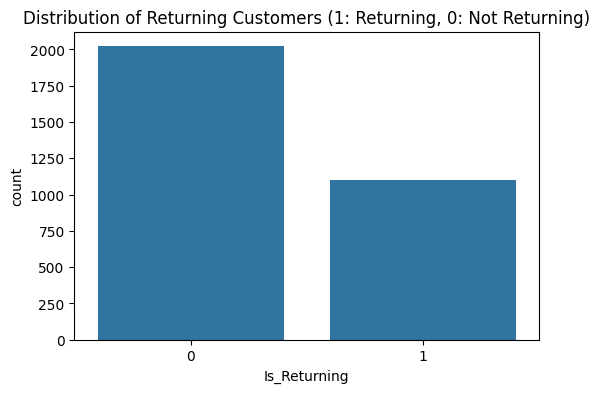

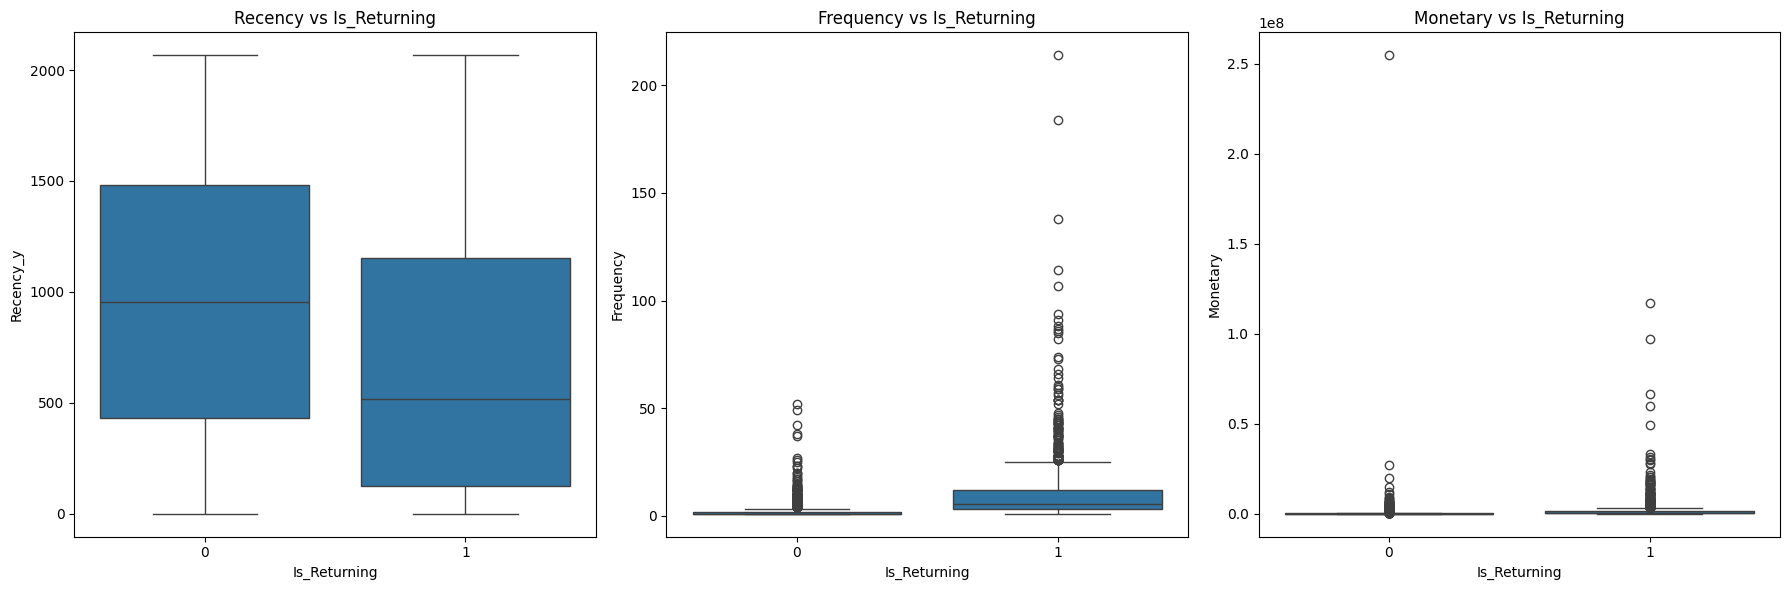

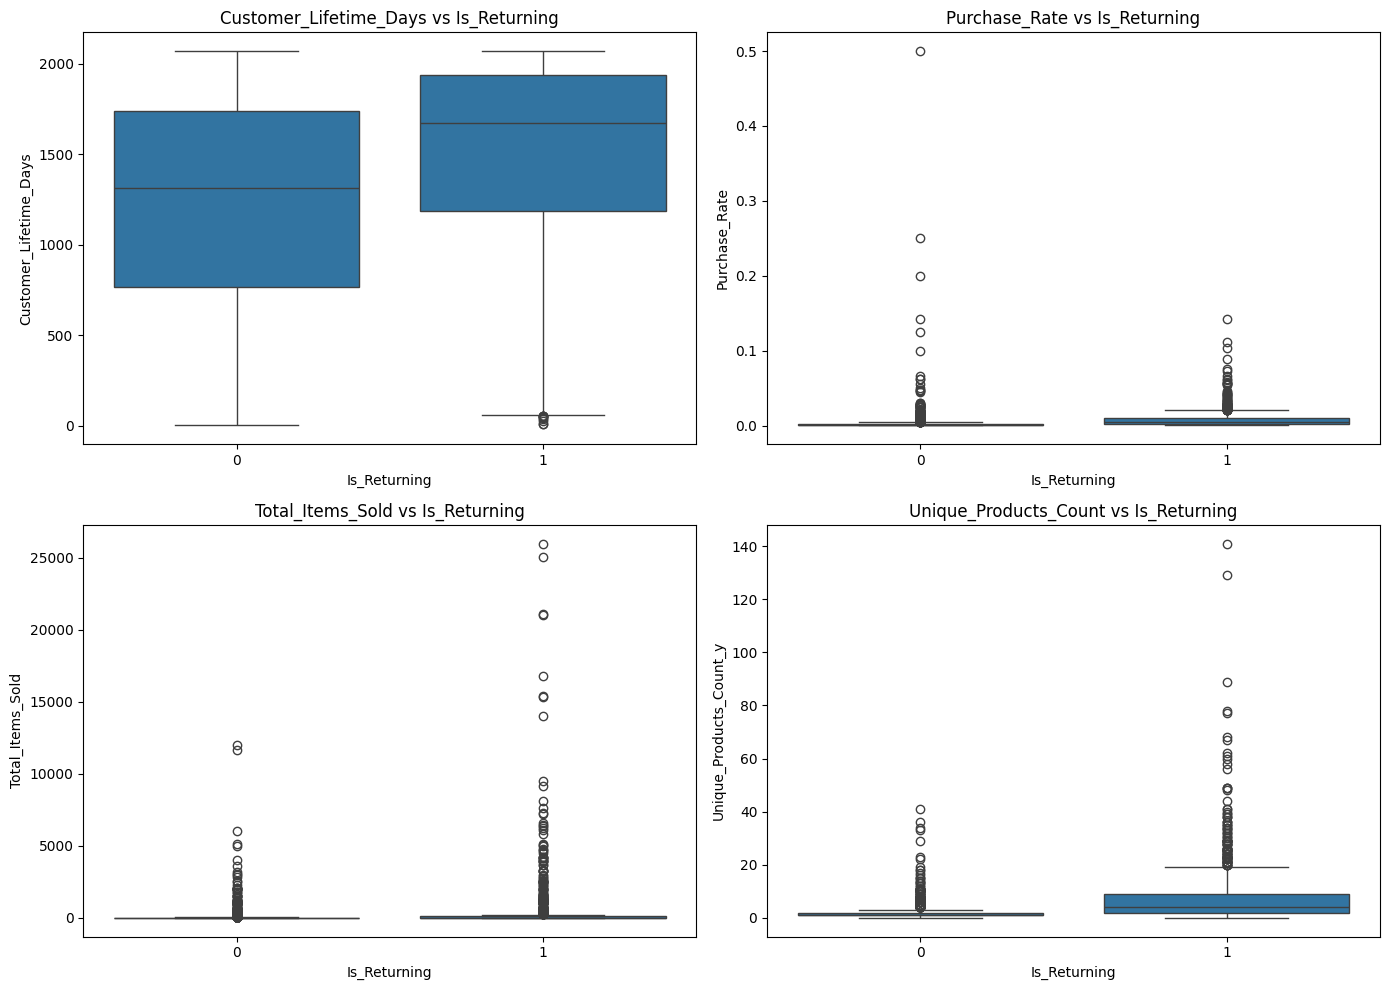

In [13]:
# Analyze the distribution of returning customers
plt.figure(figsize=(6, 4))
sns.countplot(data=rfm_data, x='Is_Returning')
plt.title('Distribution of Returning Customers (1: Returning, 0: Not Returning)')
plt.show()

# Analyze the relationship between RFM features and 'Is_Returning'
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=rfm_data, x='Is_Returning', y='Recency_y', ax=axes[0])
axes[0].set_title('Recency vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Frequency', ax=axes[1])
axes[1].set_title('Frequency vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Monetary', ax=axes[2])
axes[2].set_title('Monetary vs Is_Returning')
plt.tight_layout()
plt.show()

# Analyze the relationship between other features and 'Is_Returning'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=rfm_data, x='Is_Returning', y='Customer_Lifetime_Days', ax=axes[0, 0])
axes[0, 0].set_title('Customer_Lifetime_Days vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Purchase_Rate', ax=axes[0, 1])
axes[0, 1].set_title('Purchase_Rate vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Total_Items_Sold', ax=axes[1, 0])
axes[1, 0].set_title('Total_Items_Sold vs Is_Returning')
sns.boxplot(data=rfm_data, x='Is_Returning', y='Unique_Products_Count_y', ax=axes[1, 1])
axes[1, 1].set_title('Unique_Products_Count vs Is_Returning')
plt.tight_layout()
plt.show()

### Feature Engineering

Now, let's create relevant features from the `rfm_data` and `transaction_data` that can be used for predicting customer behavior and analyzing retention.

In [10]:
# Convert 'Date' column to datetime objects if not already
transaction_data['Date'] = pd.to_datetime(transaction_data['Date'])

# Calculate Recency (days since last purchase) for each customer
latest_date = transaction_data['Date'].max()
recency_df = transaction_data.groupby('Customer_ID')['Date'].max().reset_index()
recency_df['Recency'] = (latest_date - recency_df['Date']).dt.days
recency_df = recency_df[['Customer_ID', 'Recency']]
display(recency_df.head())

# Frequency and Monetary are already available in rfm_data

# Merge RFM data with Recency
rfm_data = rfm_data.merge(recency_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Additional features from transaction_data
# Number of unique products purchased
unique_products_df = transaction_data.groupby('Customer_ID')['Product(s)'].nunique().reset_index()
unique_products_df.rename(columns={'Product(s)': 'Unique_Products_Count'}, inplace=True)
rfm_data = rfm_data.merge(unique_products_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average items per order
avg_items_per_order_df = transaction_data.groupby('Customer_ID')['Items sold'].mean().reset_index()
avg_items_per_order_df.rename(columns={'Items sold': 'Avg_Items_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_items_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average revenue per order
avg_revenue_per_order_df = transaction_data.groupby('Customer_ID')['Revenue'].mean().reset_index()
avg_revenue_per_order_df.rename(columns={'Revenue': 'Avg_Revenue_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_revenue_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average net sales per order
avg_net_sales_per_order_df = transaction_data.groupby('Customer_ID')['Net_Sales'].mean().reset_index()
avg_net_sales_per_order_df.rename(columns={'Net_Sales': 'Avg_Net_Sales_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_net_sales_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

,Customer_ID,Recency
0,CUS000001,397
1,CUS000002,900
2,CUS000003,334
3,CUS000004,488
4,CUS000005,570


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,Unique_Products_Count,Avg_Items_Per_Order,Avg_Revenue_Per_Order,Avg_Net_Sales_Per_Order,RFM_Segment,Is_Returning,Recency_y
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,1,1.000000,8880000.00,8700000.00,1,0,397
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,2,4.500000,89625.00,84575.00,1,0,900
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,3,3.666667,183500.00,178500.00,1,1,334
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,1,2.000000,27000.00,22000.00,1,0,488
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,1,15.000000,154399.99,141099.99,1,0,570


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,Unique_Products_Count_x,Avg_Items_Per_Order,Avg_Revenue_Per_Order,Avg_Net_Sales_Per_Order,RFM_Segment,Is_Returning,Recency_y,Unique_Products_Count_y
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,1,1.000000,8880000.00,8700000.00,1,0,397,1
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,2,4.500000,89625.00,84575.00,1,0,900,2
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,3,3.666667,183500.00,178500.00,1,1,334,3
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,1,2.000000,27000.00,22000.00,1,0,488,1
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,1,15.000000,154399.99,141099.99,1,0,570,1


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,Unique_Products_Count_x,Avg_Items_Per_Order_x,Avg_Revenue_Per_Order,Avg_Net_Sales_Per_Order,RFM_Segment,Is_Returning,Recency_y,Unique_Products_Count_y,Avg_Items_Per_Order_y
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,1,1.000000,8880000.00,8700000.00,1,0,397,1,1.000000
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,2,4.500000,89625.00,84575.00,1,0,900,2,4.500000
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,3,3.666667,183500.00,178500.00,1,1,334,3,3.666667
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,1,2.000000,27000.00,22000.00,1,0,488,1,2.000000
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,1,15.000000,154399.99,141099.99,1,0,570,1,15.000000


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,Unique_Products_Count_x,Avg_Items_Per_Order_x,Avg_Revenue_Per_Order_x,Avg_Net_Sales_Per_Order,RFM_Segment,Is_Returning,Recency_y,Unique_Products_Count_y,Avg_Items_Per_Order_y,Avg_Revenue_Per_Order_y
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,1,1.000000,8880000.00,8700000.00,1,0,397,1,1.000000,8880000.00
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,2,4.500000,89625.00,84575.00,1,0,900,2,4.500000,89625.00
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,3,3.666667,183500.00,178500.00,1,1,334,3,3.666667,183500.00
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,1,2.000000,27000.00,22000.00,1,0,488,1,2.000000,27000.00
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,1,15.000000,154399.99,141099.99,1,0,570,1,15.000000,154399.99


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency_x,...,Avg_Items_Per_Order_x,Avg_Revenue_Per_Order_x,Avg_Net_Sales_Per_Order_x,RFM_Segment,Is_Returning,Recency_y,Unique_Products_Count_y,Avg_Items_Per_Order_y,Avg_Revenue_Per_Order_y,Avg_Net_Sales_Per_Order_y
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,...,1.000000,8880000.00,8700000.00,1,0,397,1,1.000000,8880000.00,8700000.00
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,...,4.500000,89625.00,84575.00,1,0,900,2,4.500000,89625.00,84575.00
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,...,3.666667,183500.00,178500.00,1,1,334,3,3.666667,183500.00,178500.00
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,...,2.000000,27000.00,22000.00,1,0,488,1,2.000000,27000.00,22000.00
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,...,15.000000,154399.99,141099.99,1,0,570,1,15.000000,154399.99,141099.99


### Predictive Modeling

Let's build a predictive model to forecast customer behavior. We can focus on predicting a target variable, such as customer churn or future purchase value, using the engineered features. For this example, let's build a classification model to predict whether a customer will be a 'returning' customer based on their RFM and other features.

First, we need to prepare the data for modeling.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define the target variable: 'returning' customer
rfm_data['Is_Returning'] = (rfm_data['Customer_Type'] == 'returning').astype(int)

# Select features and target
# Corrected feature names based on the dataframe after merging
features = ['Recency_y', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Rate', 'Total_Items_Sold', 'Unique_Products_Count_y', 'Avg_Items_Per_Order_y', 'Avg_Revenue_Per_Order_y', 'Avg_Net_Sales_Per_Order_y']
target = 'Is_Returning'

X = rfm_data[features]
y = rfm_data[target]

# Handle missing values in features (using mean imputation as done previously)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

/tmp/ipython-input-1030505994.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-1030505994.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


Accuracy: 0.8591248665955176
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       605
           1       0.80      0.80      0.80       332

    accuracy                           0.86       937
   macro avg       0.85      0.85      0.85       937
weighted avg       0.86      0.86      0.86       937



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define the target variable: 'returning' customer
rfm_data['Is_Returning'] = (rfm_data['Customer_Type'] == 'returning').astype(int)

# Select features and target
features = ['Recency', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Rate', 'Total_Items_Sold', 'Unique_Products_Count', 'Avg_Items_Per_Order', 'Avg_Revenue_Per_Order', 'Avg_Net_Sales_Per_Order']
target = 'Is_Returning'

X = rfm_data[features]
y = rfm_data[target]

# Handle missing values in features (using mean imputation as done previously)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

/tmp/ipython-input-3398480370.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-3398480370.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


Accuracy: 0.8591248665955176
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       605
           1       0.80      0.80      0.80       332

    accuracy                           0.86       937
   macro avg       0.85      0.85      0.85       937
weighted avg       0.86      0.86      0.86       937



### Predictive Modeling

Let's build a predictive model to forecast customer behavior. We can focus on predicting a target variable, such as customer churn or future purchase value, using the engineered features. For this example, let's build a classification model to predict whether a customer will be a 'returning' customer based on their RFM and other features.

First, we need to prepare the data for modeling.

### Customer Segmentation

Let's segment customers based on their characteristics and behavior using K-Means clustering on the RFM features.

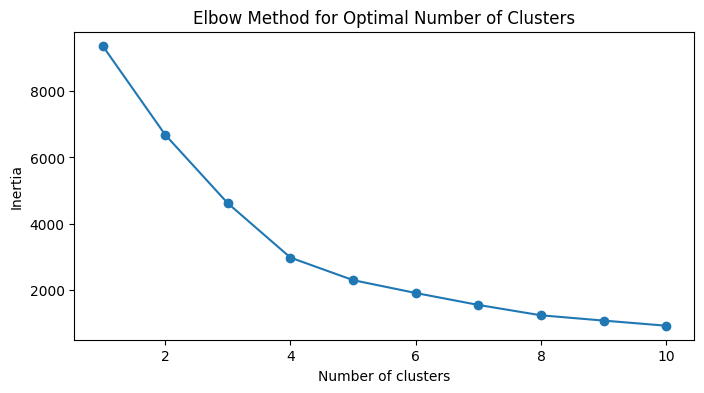

,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Rate,Total_Items_Sold,Unique_Products_Count,Avg_Items_Per_Order,Avg_Revenue_Per_Order,Avg_Net_Sales_Per_Order
RFM_Segment,,,,,,,,,,
0,1458.897784,2.134382,2.880798e+05,1573.586848,0.001335,109.525375,1.557541,57.020109,1.594063e+05,1.440081e+05
1,390.943574,4.891536,7.882922e+05,1044.528527,0.006911,158.746708,3.904075,38.229080,2.364470e+05,2.163301e+05
2,92.000000,38.666667,1.562694e+08,1331.000000,0.020931,12782.333333,28.333333,1373.181658,5.040143e+07,4.832446e+07
3,128.000000,44.112000,8.863844e+06,1931.584000,0.022997,2116.288000,31.504000,65.677335,3.326147e+05,3.082173e+05


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select RFM features for clustering
rfm_features = rfm_data[['Recency', 'Frequency', 'Monetary']].copy()

# Handle potential infinite values by replacing them with NaN and then imputing with the mean
rfm_features.replace([np.inf, -np.inf], np.nan, inplace=True)
rfm_features.fillna(rfm_features.mean(), inplace=True)


# Scale the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Determine the optimal number of clusters using the elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

# Based on the elbow method, let's choose a number of clusters (e.g., 4)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
rfm_data['RFM_Segment'] = kmeans.fit_predict(rfm_scaled)

# Analyze the characteristics of each segment
segment_analysis = rfm_data.groupby('RFM_Segment')[['Recency', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Rate', 'Total_Items_Sold', 'Unique_Products_Count', 'Avg_Items_Per_Order', 'Avg_Revenue_Per_Order', 'Avg_Net_Sales_Per_Order']].mean()
display(segment_analysis)

### Exploratory Data Analysis (EDA)

Let's perform some exploratory data analysis to understand the distribution of key variables, identify trends in customer behavior, and visualize relationships between different features.

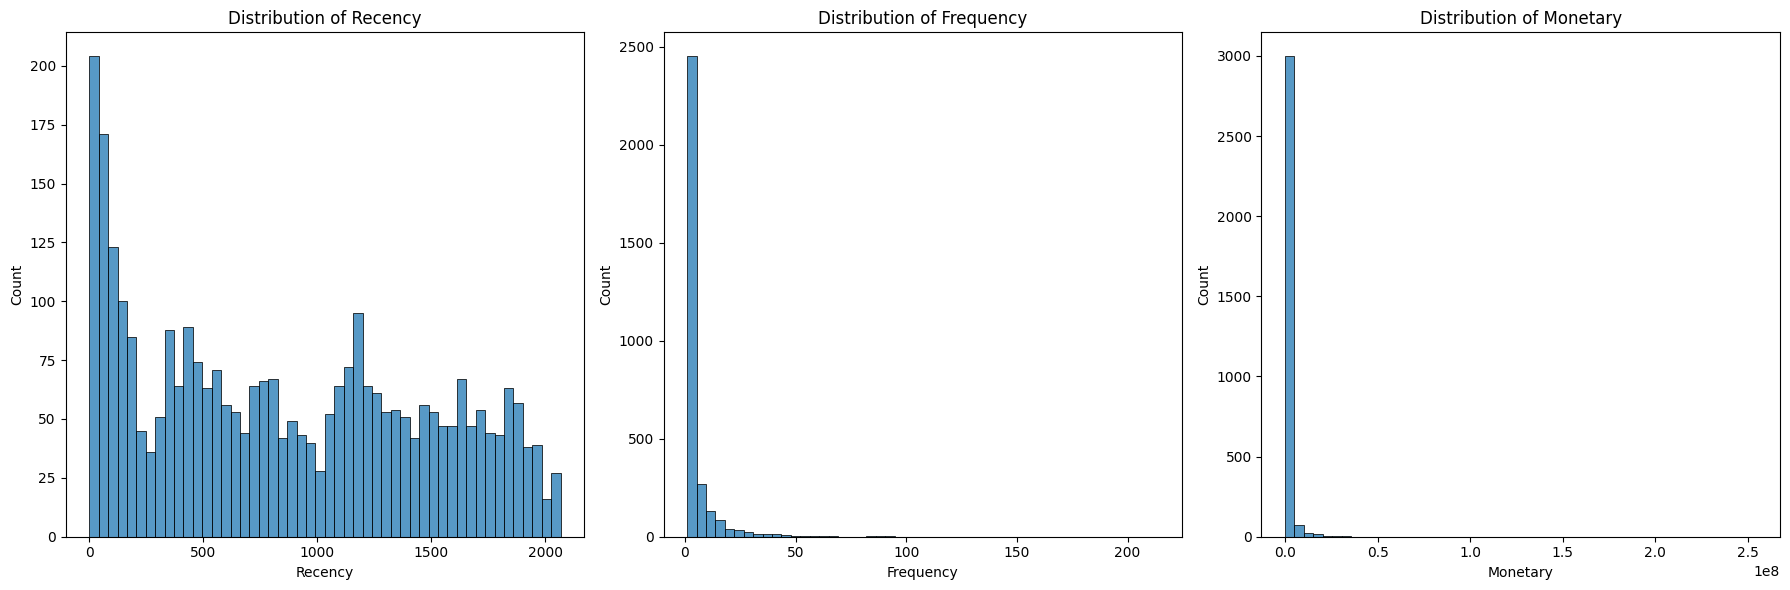

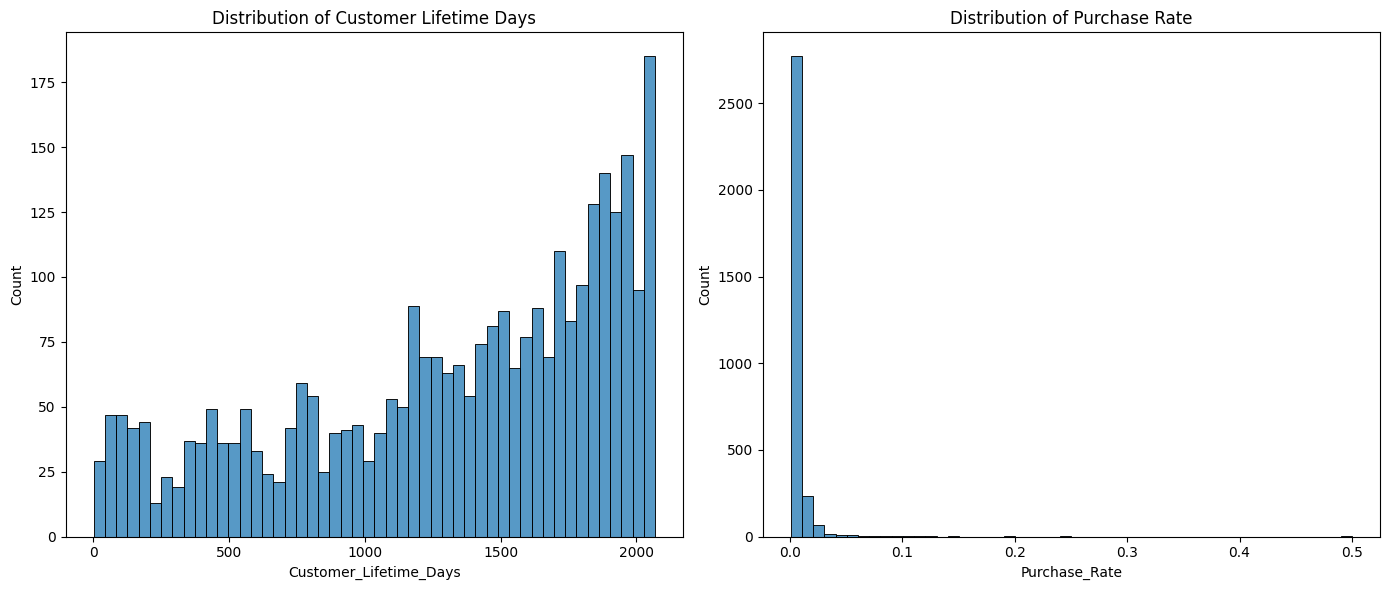

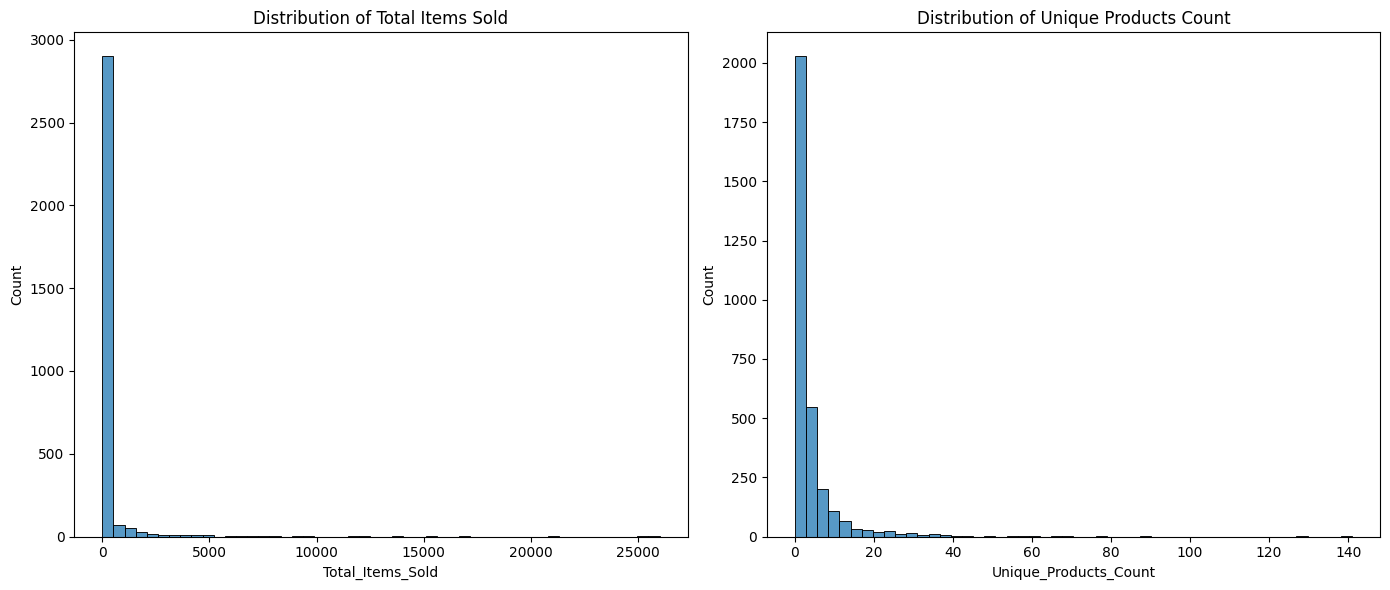

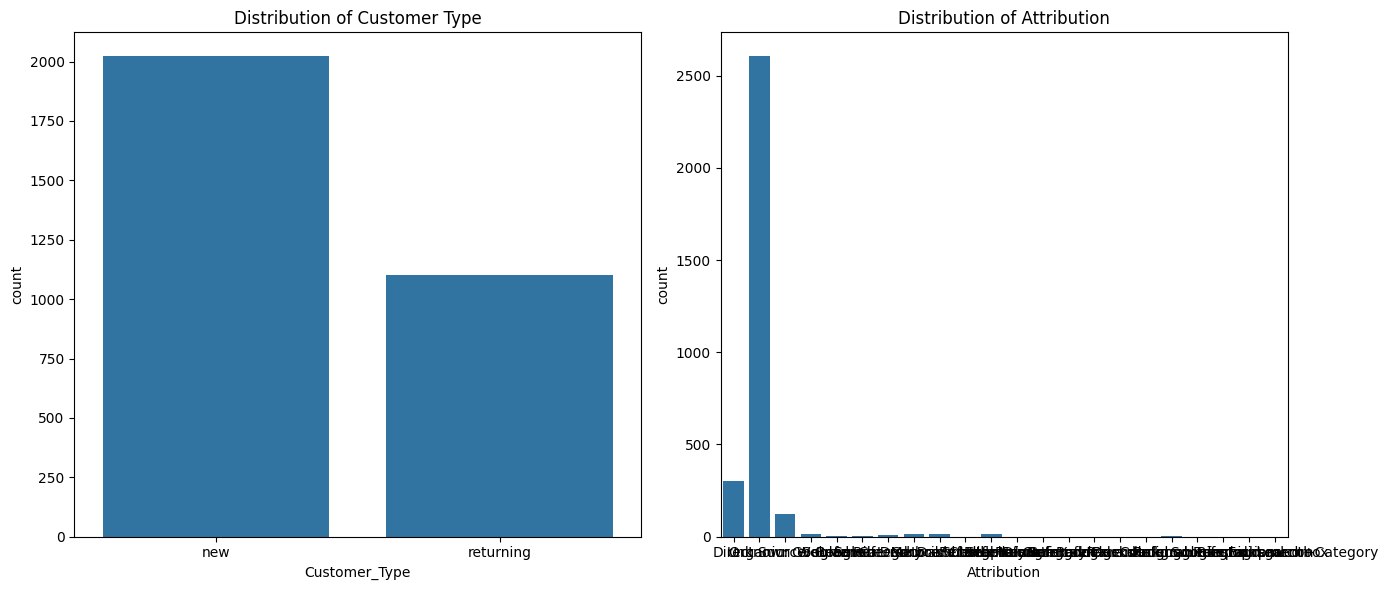

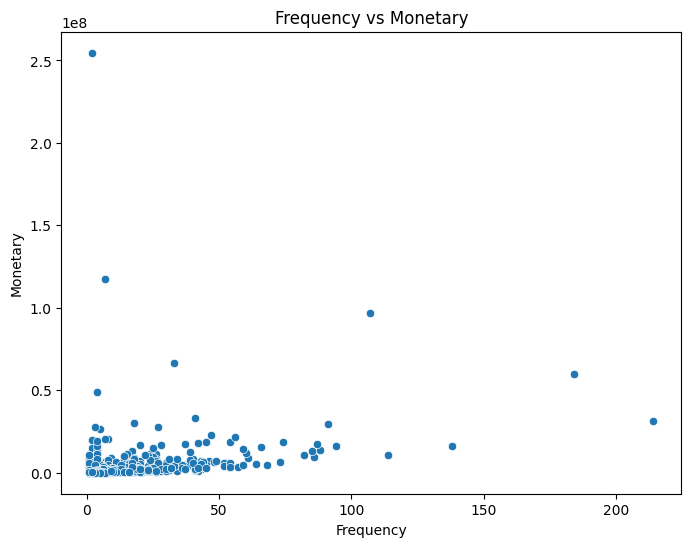

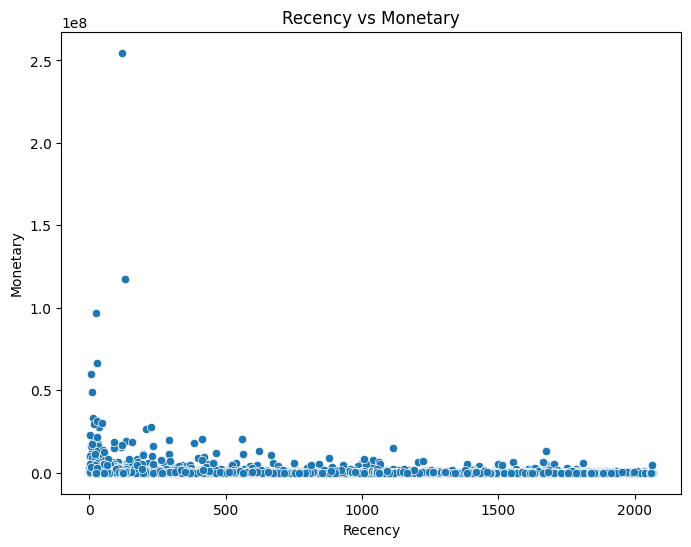

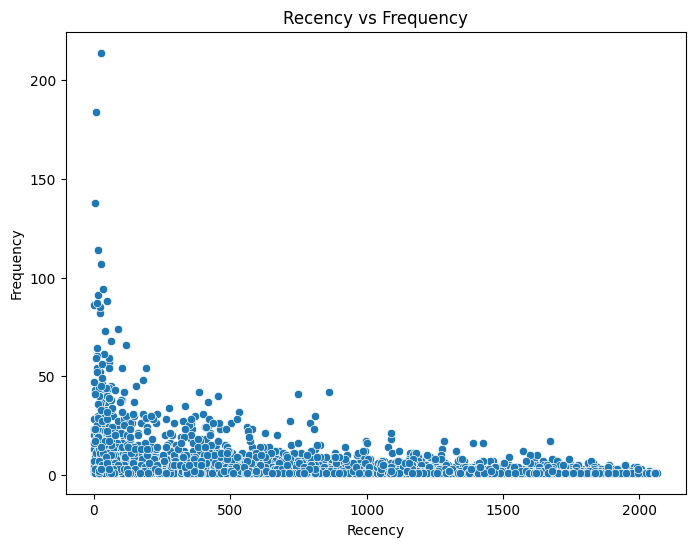

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Recency, Frequency, and Monetary
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(rfm_data['Recency'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Recency')
sns.histplot(rfm_data['Frequency'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Frequency')
sns.histplot(rfm_data['Monetary'], bins=50, ax=axes[2])
axes[2].set_title('Distribution of Monetary')
plt.tight_layout()
plt.show()

# Distribution of Customer_Lifetime_Days and Purchase_Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(rfm_data['Customer_Lifetime_Days'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Customer Lifetime Days')
sns.histplot(rfm_data['Purchase_Rate'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Purchase Rate')
plt.tight_layout()
plt.show()

# Distribution of Total_Items_Sold and Unique_Products_Count
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(rfm_data['Total_Items_Sold'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Total Items Sold')
sns.histplot(rfm_data['Unique_Products_Count'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Unique Products Count')
plt.tight_layout()
plt.show()

# Distribution of Customer_Type and Attribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=rfm_data, x='Customer_Type', ax=axes[0])
axes[0].set_title('Distribution of Customer Type')
sns.countplot(data=rfm_data, x='Attribution', ax=axes[1])
axes[1].set_title('Distribution of Attribution')
plt.tight_layout()
plt.show()

# Relationship between Frequency and Monetary
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_data, x='Frequency', y='Monetary')
plt.title('Frequency vs Monetary')
plt.show()

# Relationship between Recency and Monetary
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_data, x='Recency', y='Monetary')
plt.title('Recency vs Monetary')
plt.show()

# Relationship between Recency and Frequency
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm_data, x='Recency', y='Frequency')
plt.title('Recency vs Frequency')
plt.show()

### Feature Engineering

Now, let's create relevant features from the `rfm_data` and `transaction_data` that can be used for predicting customer behavior and analyzing retention.

In [6]:
# Convert 'Date' column to datetime objects if not already
transaction_data['Date'] = pd.to_datetime(transaction_data['Date'])

# Calculate Recency (days since last purchase) for each customer
latest_date = transaction_data['Date'].max()
recency_df = transaction_data.groupby('Customer_ID')['Date'].max().reset_index()
recency_df['Recency'] = (latest_date - recency_df['Date']).dt.days
recency_df = recency_df[['Customer_ID', 'Recency']]
display(recency_df.head())

# Frequency and Monetary are already available in rfm_data

# Merge RFM data with Recency
rfm_data = rfm_data.merge(recency_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Additional features from transaction_data
# Number of unique products purchased
unique_products_df = transaction_data.groupby('Customer_ID')['Product(s)'].nunique().reset_index()
unique_products_df.rename(columns={'Product(s)': 'Unique_Products_Count'}, inplace=True)
rfm_data = rfm_data.merge(unique_products_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average items per order
avg_items_per_order_df = transaction_data.groupby('Customer_ID')['Items sold'].mean().reset_index()
avg_items_per_order_df.rename(columns={'Items sold': 'Avg_Items_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_items_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average revenue per order
avg_revenue_per_order_df = transaction_data.groupby('Customer_ID')['Revenue'].mean().reset_index()
avg_revenue_per_order_df.rename(columns={'Revenue': 'Avg_Revenue_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_revenue_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

# Average net sales per order
avg_net_sales_per_order_df = transaction_data.groupby('Customer_ID')['Net_Sales'].mean().reset_index()
avg_net_sales_per_order_df.rename(columns={'Net_Sales': 'Avg_Net_Sales_Per_Order'}, inplace=True)
rfm_data = rfm_data.merge(avg_net_sales_per_order_df, on='Customer_ID', how='left')
display(rfm_data.head())

,Customer_ID,Recency
0,CUS000001,397
1,CUS000002,900
2,CUS000003,334
3,CUS000004,488
4,CUS000005,570


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency,Unique_Products_Count
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,1
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,2
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,3
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,1
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,1


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency,Unique_Products_Count,Avg_Items_Per_Order
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,1,1.000000
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,2,4.500000
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,3,3.666667
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,1,2.000000
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,1,15.000000


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency,Unique_Products_Count,Avg_Items_Per_Order,Avg_Revenue_Per_Order
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,1,1.000000,8880000.00
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,2,4.500000,89625.00
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,3,3.666667,183500.00
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,1,2.000000,27000.00
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,1,15.000000,154399.99


,Customer_ID,Frequency,Monetary,Avg_Order_Value,Customer_Lifetime_Days,Purchase_Rate,Customer_Type,Attribution,Total_Items_Sold,Recency,Unique_Products_Count,Avg_Items_Per_Order,Avg_Revenue_Per_Order,Avg_Net_Sales_Per_Order
0,CUS000001,1,8700000.00,8700000.00,397,0.002513,new,Direct,1,397,1,1.000000,8880000.00,8700000.00
1,CUS000002,2,169150.00,84575.00,1357,0.001473,new,Unknown,9,900,2,4.500000,89625.00,84575.00
2,CUS000003,3,535500.00,178500.00,384,0.007792,returning,Direct,11,334,3,3.666667,183500.00,178500.00
3,CUS000004,1,22000.00,22000.00,488,0.002045,new,Unknown,2,488,1,2.000000,27000.00,22000.00
4,CUS000005,1,141099.99,141099.99,570,0.001751,new,Direct,15,570,1,15.000000,154399.99,141099.99


### Data Preprocessing and Cleaning

First, we will inspect the `rfm_data` and `transaction_data` DataFrames for missing values, outliers, and data types. Then, we will clean and transform the data as necessary to prepare it for analysis.

In [5]:
# Inspect data types and missing values for rfm_data
print("rfm_data Info:")
rfm_data.info()
print("\nrfm_data Missing Values:")
print(rfm_data.isnull().sum())

# Inspect data types and missing values for transaction_data
print("\nTransaction_data Info:")
transaction_data.info()
print("\nTransaction_data Missing Values:")
print(transaction_data.isnull().sum())

rfm_data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3122 entries, 0 to 3121
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             3122 non-null   object 
 1   Frequency               3122 non-null   int64  
 2   Monetary                3122 non-null   float64
 3   Avg_Order_Value         3122 non-null   float64
 4   Customer_Lifetime_Days  3122 non-null   int64  
 5   Purchase_Rate           3122 non-null   float64
 6   Customer_Type           3122 non-null   object 
 7   Attribution             3122 non-null   object 
 8   Total_Items_Sold        3122 non-null   int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 219.6+ KB

rfm_data Missing Values:
Customer_ID               0
Frequency                 0
Monetary                  0
Avg_Order_Value           0
Customer_Lifetime_Days    0
Purchase_Rate             0
Customer_Type             0
Attributio